# CCI

In [56]:
pip install comorbidipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [57]:
pip install pyomop

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [32]:

from pyomop import CdmEngineFactory #pyomop equivalant Python library of comorbidipy which connects with SQLite and also


cdm = CdmEngineFactory()
#metadata.create_all(cdm.engine)
session = cdm.session

 


In [33]:

#basic querrying to understand the ETL
table_list = cdm.engine.table_names()

print("Tables in the database:")
for table in table_list:
    print(table)


Tables in the database:
attribute_definition
care_site
cdm_source
cohort
cohort_attribute
cohort_definition
concept
concept_ancestor
concept_class
concept_relationship
concept_synonym
condition_era
condition_occurrence
death
device_cost
device_exposure
domain
dose_era
drug_cost
drug_era
drug_exposure
drug_strength
fact_relationship
location
measurement
note
observation
observation_period
payer_plan_period
person
procedure_cost
procedure_occurrence
provider
relationship
source_to_concept_map
specimen
visit_cost
visit_occurrence
vocabulary


In [34]:
#Schema 

schema_list = cdm.engine.dialect.get_schema_names(cdm.engine.connect())

print("Schemas in the database:")
for schema in schema_list:
    print(schema)


Schemas in the database:
main


In [62]:
#cdm engine is under omop which is omop cdm, which helps to pull the etl of common data model

from sqlalchemy import text

# Create a raw SQL statement to fetch data from the person table
stmt = text("SELECT * FROM main.person")

# Execute the statement
result = cdm.engine.execute(stmt)

#result

# Fetch all rows from the result
persons = result.fetchall()

persons

# Print the rows
#for person in persons:
    #print(person)


[]

In [63]:
# there is zero record here as you can see ##



stmt_count = text("SELECT COUNT(*) FROM person")

# Execute the statement
result_count = cdm.engine.execute(stmt_count)

# Fetch the count
record_count = result_count.scalar()

print(f"Number of records in the 'person' table: {record_count}")


Number of records in the 'person' table: 0


###Adding Mock Data 

In [64]:

import pandas as pd
import random
from faker import Faker


#PERSON

# Ensure reproducibility
random.seed(999)
fake = Faker()

# Create fake data for the PERSON table

# Use faker library to generate sample patient data (create 100 sample patients)
first_names = [fake.first_name() for _ in range(100)]
last_names = [fake.last_name() for _ in range(100)]

dat_pers = pd.DataFrame({'first_name': first_names, 'last_name': last_names})

# Add additional columns to mimic the PERSON data
dat_pers['person_id'] = random.sample(range(100000, 999999), 100)  # random 6 digit unique patient id
dat_pers['year_of_birth'] = [random.choice(range(1916, 2017)) for _ in range(100)]  # restrict to <= 100 years old between 1916-2016
dat_pers['ethnicity_concept_id'] = [random.choice([1, 2, 3]) for _ in range(100)]  # values of 1, 2, & 3 would have a lookup table in the CDM

# Rename and select columns to match the desired structure
dat_pers2 = dat_pers.rename(columns={"first_name": "gender_concept_id", "last_name": "race_concept_id"})
dat_pers2 = dat_pers2[['person_id', 'gender_concept_id', 'year_of_birth', 'race_concept_id', 'ethnicity_concept_id']]

# Display first 5 persons
dat_pers2.head()


,person_id,gender_concept_id,year_of_birth,race_concept_id,ethnicity_concept_id
0,919301,Richard,1920,Pena,2
1,811783,Angela,1968,Moran,2
2,183954,Leslie,1983,Arnold,3
3,695367,Christine,1926,Hernandez,2
4,701625,Amanda,2014,Tanner,1


In [65]:
#as it is given on the task list i started to populate related tables. here is the second one which is observation period 


import pandas as pd
import random
import numpy as np
from datetime import date, timedelta

#OBS Period

# Use the same person_ids from above
# Generate observation_period_id and person_id
dat_obs = pd.DataFrame({
    'observation_period_id': random.sample(range(1000000, 9999999), 100),  # random 7 digit unique id, assume only 1 per person
    'person_id': dat_pers2['person_id'].sample(frac=1).reset_index(drop=True)  # shuffle the person_ids
})

# Join the dat_pers2 and dat_obs dataframes on person_id for date calculations
dat_obs_pers2_fordate = pd.merge(dat_pers2, dat_obs, on='person_id')[['person_id', 'year_of_birth', 'observation_period_id']]

# Define function to generate observation start and end dates based on year_of_birth
def generate_dates(row):
    year_of_birth_lastday = date(row['year_of_birth'], 12, 31)
    obs_start = year_of_birth_lastday + timedelta(days=np.random.randint(0, 365*5 + 1))
    obs_end = obs_start + timedelta(days=np.random.randint(365, (date.today() - obs_start).days + 1))
    return pd.Series([obs_start, obs_end], index=['observation_period_start_date', 'observation_period_end_date'])

# Apply function to dat_obs_pers2_fordate
dat_obs_pers2_fordate[['observation_period_start_date', 'observation_period_end_date']] = dat_obs_pers2_fordate.apply(generate_dates, axis=1)

# Drop year_of_birth as it's not needed in the final observation data
dat_obs2 = dat_obs_pers2_fordate.drop(columns='year_of_birth')

# Display first 5 observation periods
dat_obs2.head()


,person_id,observation_period_id,observation_period_start_date,observation_period_end_date
0,919301,8087705,1925-08-12,1982-05-12
1,811783,6217322,1970-01-22,1973-08-02
2,183954,3866788,1987-04-17,2019-12-28
3,695367,5943353,1930-01-19,1967-11-23
4,701625,2300385,2018-07-24,2022-03-08


In [66]:
import numpy as np
from datetime import date, timedelta

#DRUG

# Create drug_exposure data with the given specifications
dat_drug = pd.DataFrame({
    'drug_exposure_id': random.sample(range(1000000, 9999999), 500),  # random 7 digit unique id 
    'person_id': np.random.choice(dat_pers2['person_id'], 500),  # random person_ids with replacement
    'drug_concept_id': np.random.choice(range(1, 21), 500)  # simulate 10 different drug options
})

# Join the dat_pers2 and dat_drug dataframes on person_id for date calculations
dat_drug_pers2_fordate = pd.merge(dat_pers2, dat_drug, on='person_id')[['person_id', 'year_of_birth', 'drug_exposure_id', 'drug_concept_id']]

# Define function to generate drug exposure start and end dates based on year_of_birth
def generate_drug_dates(row):
    year_of_birth_lastday = date(row['year_of_birth'], 12, 31)
    drug_start = year_of_birth_lastday + timedelta(days=np.random.randint(0, 360*5 + 1))
    drug_end = drug_start + timedelta(days=np.random.randint(365, (date.today() - drug_start).days + 1))
    return pd.Series([drug_start, drug_end], index=['drug_exposure_start_date', 'drug_exposure_end_date'])

# Apply function to dat_drug_pers2_for date
dat_drug_pers2_fordate[['drug_exposure_start_date', 'drug_exposure_end_date']] = dat_drug_pers2_fordate.apply(generate_drug_dates, axis=1)

# Drop year_of_birth as it's not needed in the final drug exposure data
dat_drug2 = dat_drug_pers2_fordate.drop(columns='year_of_birth')[['drug_exposure_id', 'person_id', 'drug_concept_id', 'drug_exposure_start_date', 'drug_exposure_end_date']]

# Display first 5 drug exposures
dat_drug2.head()


,drug_exposure_id,person_id,drug_concept_id,drug_exposure_start_date,drug_exposure_end_date
0,4327487,919301,14,1924-06-02,1926-09-17
1,2772660,919301,2,1924-11-23,2007-11-22
2,2522874,811783,4,1972-06-07,2009-04-18
3,9081051,811783,9,1973-04-07,2005-03-24
4,4459060,811783,9,1972-11-28,2005-03-04


In [67]:
import numpy as np
from datetime import date, timedelta

# Diseases_ cond occurance

# Create condition_occurrence data with the given specifications
dat_cond = pd.DataFrame({
    'condition_occurrence_id': random.sample(range(1000000, 9999999), 500),  # random 7 digit unique id 
    'person_id': np.random.choice(dat_pers2['person_id'], 500),  # random person_ids with replacement
    'condition_concept_id': np.random.choice(range(1, 21), 500)  # simulate 10 different condition options
})

# Join the dat_pers2 and dat_cond dataframes on person_id for date calculations
dat_cond_pers2_fordate = pd.merge(dat_pers2, dat_cond, on='person_id')[['person_id', 'year_of_birth', 'condition_occurrence_id', 'condition_concept_id']]

# Define function to generate condition start and end dates based on year_of_birth
def generate_condition_dates(row):
    year_of_birth_lastday = date(row['year_of_birth'], 12, 31)
    condition_start = year_of_birth_lastday + timedelta(days=np.random.randint(0, 360*5 + 1))
    condition_end = condition_start + timedelta(days=np.random.randint(365, (date.today() - condition_start).days + 1))
    return pd.Series([condition_start, condition_end], index=['condition_start_date', 'condition_end_date'])

# Apply function to dat_cond_pers2_fordate
dat_cond_pers2_fordate[['condition_start_date', 'condition_end_date']] = dat_cond_pers2_fordate.apply(generate_condition_dates, axis=1)

# Drop year_of_birth as it's not needed in the final condition occurrence data
dat_cond2 = dat_cond_pers2_fordate.drop(columns='year_of_birth')[['condition_occurrence_id', 'person_id', 'condition_concept_id', 'condition_start_date', 'condition_end_date']]

# Display first 5 condition occurrences
dat_cond2.head()


,condition_occurrence_id,person_id,condition_concept_id,condition_start_date,condition_end_date
0,6314396,919301,8,1925-04-04,1995-07-20
1,8241538,919301,18,1921-10-22,1959-05-02
2,3568185,919301,1,1922-11-03,2023-06-11
3,3387314,811783,13,1972-01-25,2007-04-03
4,2143518,811783,2,1973-10-05,2016-05-03


In [68]:
import pandas as pd
from comorbidipy import comorbidity

##got the codes manually from the ICD-9 table 

# Create the lookup table
dat_condition_lookup = pd.DataFrame({
    'condition_concept_id': range(1, 21),
    'condition_descr': ["I21", "I428", "I70", "G45", "F00", "I278", "M05", "K25", "B18", 
                       "E100", "E102", "G041", "I120", "C00", "I850", "C77", "B20",
                       "N0P3", "N00", "N3G"]
})

print(dat_condition_lookup)


    condition_concept_id condition_descr
0                      1             I21
1                      2            I428
2                      3             I70
3                      4             G45
4                      5             F00
5                      6            I278
6                      7             M05
7                      8             K25
8                      9             B18
9                     10            E100
10                    11            E102
11                    12            G041
12                    13            I120
13                    14             C00
14                    15            I850
15                    16             C77
16                    17             B20
17                    18            N0P3
18                    19             N00
19                    20             N3G


In [71]:
# Renaming the 'condition_descr' column to 'code' in the dat_condition_lookup DataFrame
dat_condition_lookup = dat_condition_lookup.rename(columns={"condition_descr": "code"})

# Now compute the Charlson Comorbidity Index
charlson_scores = comorbidity(df=dat_condition_lookup, 
                              id='condition_concept_id', 
                              code='code', 
                              age=None, 
                              score='charlson', 
                              icd='icd10', 
                              variant='quan', 
                              weighting='quan', 
                              assign0=True)

# Display the results
charlson_scores.head(20)


,condition_concept_id,aids,ami,canc,cevd,chf,copd,dementia,diab,diabwc,hp,metacanc,mld,msld,pud,pvd,rend,rheumd,comorbidity_score
0,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
5,6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
7,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0
9,10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
# Ensure the column is of date type
dat_drug2['drug_exposure_start_date'] = pd.to_datetime(dat_drug2['drug_exposure_start_date'])

# Now let's perform the grouping and identification of the first exposure as before:
dat_drug_first = dat_drug2.copy()
dat_drug_first['min_drug_exposure_start_date'] = dat_drug_first.groupby(['person_id', 'drug_concept_id'])['drug_exposure_start_date'].transform(min)
dat_drug_first['first_exposure'] = (dat_drug_first['drug_exposure_start_date'] == dat_drug_first['min_drug_exposure_start_date']).astype(int)

# Create first_exposure_id column
def get_first_exposure_id(group):
    return group.loc[group['drug_exposure_start_date'].idxmin(), 'drug_exposure_id']

dat_drug_first['first_exposure_id'] = dat_drug_first.groupby(['person_id', 'drug_concept_id']).apply(get_first_exposure_id).reset_index(level=['person_id', 'drug_concept_id'], drop=True)

# Filter rows where first_exposure is 1
dat_drug_first2 = dat_drug_first[dat_drug_first['first_exposure'] == 1].copy()

# Drop the temporary column
dat_drug_first2.drop('min_drug_exposure_start_date', axis=1, inplace=True)

# Display the resulting dataframe
dat_drug_first2.head()


,drug_exposure_id,person_id,drug_concept_id,drug_exposure_start_date,drug_exposure_end_date,first_exposure,first_exposure_id
0,4327487,919301,14,1924-06-02,1926-09-17,1,7378258.0
1,2772660,919301,2,1924-11-23,2007-11-22,1,6291028.0
2,2522874,811783,4,1972-06-07,2009-04-18,1,1344921.0
4,4459060,811783,9,1972-11-28,2005-03-04,1,4988420.0
5,1805305,811783,2,1969-02-19,2007-08-26,1,1359771.0


In [73]:
# Filter rows where first_exposure is 0
dat_drug_first_filtered_persons = dat_drug_first[dat_drug_first['first_exposure'] == 0]

# Sort by person_id in descending order
dat_drug_first_filtered_persons = dat_drug_first_filtered_persons.sort_values(by='person_id', ascending=False)

# Display the first 6 rows
dat_drug_first_filtered_persons.head(6)



,drug_exposure_id,person_id,drug_concept_id,drug_exposure_start_date,drug_exposure_end_date,min_drug_exposure_start_date,first_exposure,first_exposure_id
79,8006803,986193,16,1983-03-14,2005-03-25,1981-06-05,0,9337352.0
309,9770807,983607,6,1969-10-14,2005-04-01,1969-02-09,0,6969400.0
144,6734390,974127,7,1980-12-02,2010-11-16,1979-01-11,0,8571858.0
149,1981095,974127,10,1980-11-06,1996-04-03,1979-08-19,0,1217059.0
44,9511197,937459,15,1924-11-23,2019-04-03,1924-03-16,0,9711511.0
436,6573488,934256,18,2011-09-18,2013-03-12,2011-08-12,0,3800056.0


In [74]:

#is disease occured before the drug usage? need to be checked as the condition_occurance table date !!
## checked the date_drug_2 from the drug exposure table


import pandas as pd

# Subset the new filtered drug data to only relevant columns
dat_drug_first3 = dat_drug_first2[['person_id', 'drug_concept_id', 'drug_exposure_start_date']]

# Join each dataframe together, by person_id
dat_drug_and_cond = pd.merge(dat_drug_first3, dat_cond2, on='person_id')

# Filter rows where drug ids and condition ids match
dat_drug_and_cond['condition_matches_drug_id'] = dat_drug_and_cond['condition_concept_id'].isin(dat_drug_and_cond['drug_concept_id']).astype(int)
dat_drug_and_cond_match2 = dat_drug_and_cond[dat_drug_and_cond['condition_matches_drug_id'] == 1]

# Ensure that the diagnosis occurs on or after the date of earliest drug exposure
dat_drug_and_cond_match2['drug_on_or_after_condition'] = (dat_drug_and_cond_match2['condition_start_date'] <= dat_drug_and_cond_match2['drug_exposure_start_date']).astype(int)
dat_drug_and_cond_match4 = dat_drug_and_cond_match2[dat_drug_and_cond_match2['drug_on_or_after_condition'] == 1]

# Get distinct conditions per person
dat_conds_by_person = dat_drug_and_cond_match4[['person_id', 'condition_concept_id']].drop_duplicates()

# Display the first 13 rows
print(dat_conds_by_person.head(50))


     person_id  condition_concept_id
1       919301                    18
2       919301                     1
6       811783                    13
8       811783                     2
9       811783                    17
26      183954                    13
27      183954                     8
28      183954                    15
29      183954                    18
30      183954                     1
32      695367                    18
37      695367                     5
38      695367                    13
77      659626                     8
78      659626                    11
79      659626                     9
80      659626                    19
89      614385                    13
91      614385                    11
92      614385                    10
94      614385                    16
98      606866                    18
99      606866                    15
100     606866                    14
101     606866                    10
113     238486                     2
1

In [75]:
# Merge the dat_conds_by_person dataframe with dat_condition_lookup
dat_conds_by_person_decoded = pd.merge(dat_conds_by_person, dat_condition_lookup, how='inner', on='condition_concept_id')

# Drop the condition_concept_id column
dat_conds_by_person_decoded = dat_conds_by_person_decoded.drop(columns=['condition_concept_id'])

dat_conds_by_person_decoded


,person_id,code
0,919301,N0P3
1,183954,N0P3
2,695367,N0P3
3,606866,N0P3
4,433570,N0P3
...,...,...
345,207035,I278
346,117150,I278
347,254732,I278
348,357727,I278


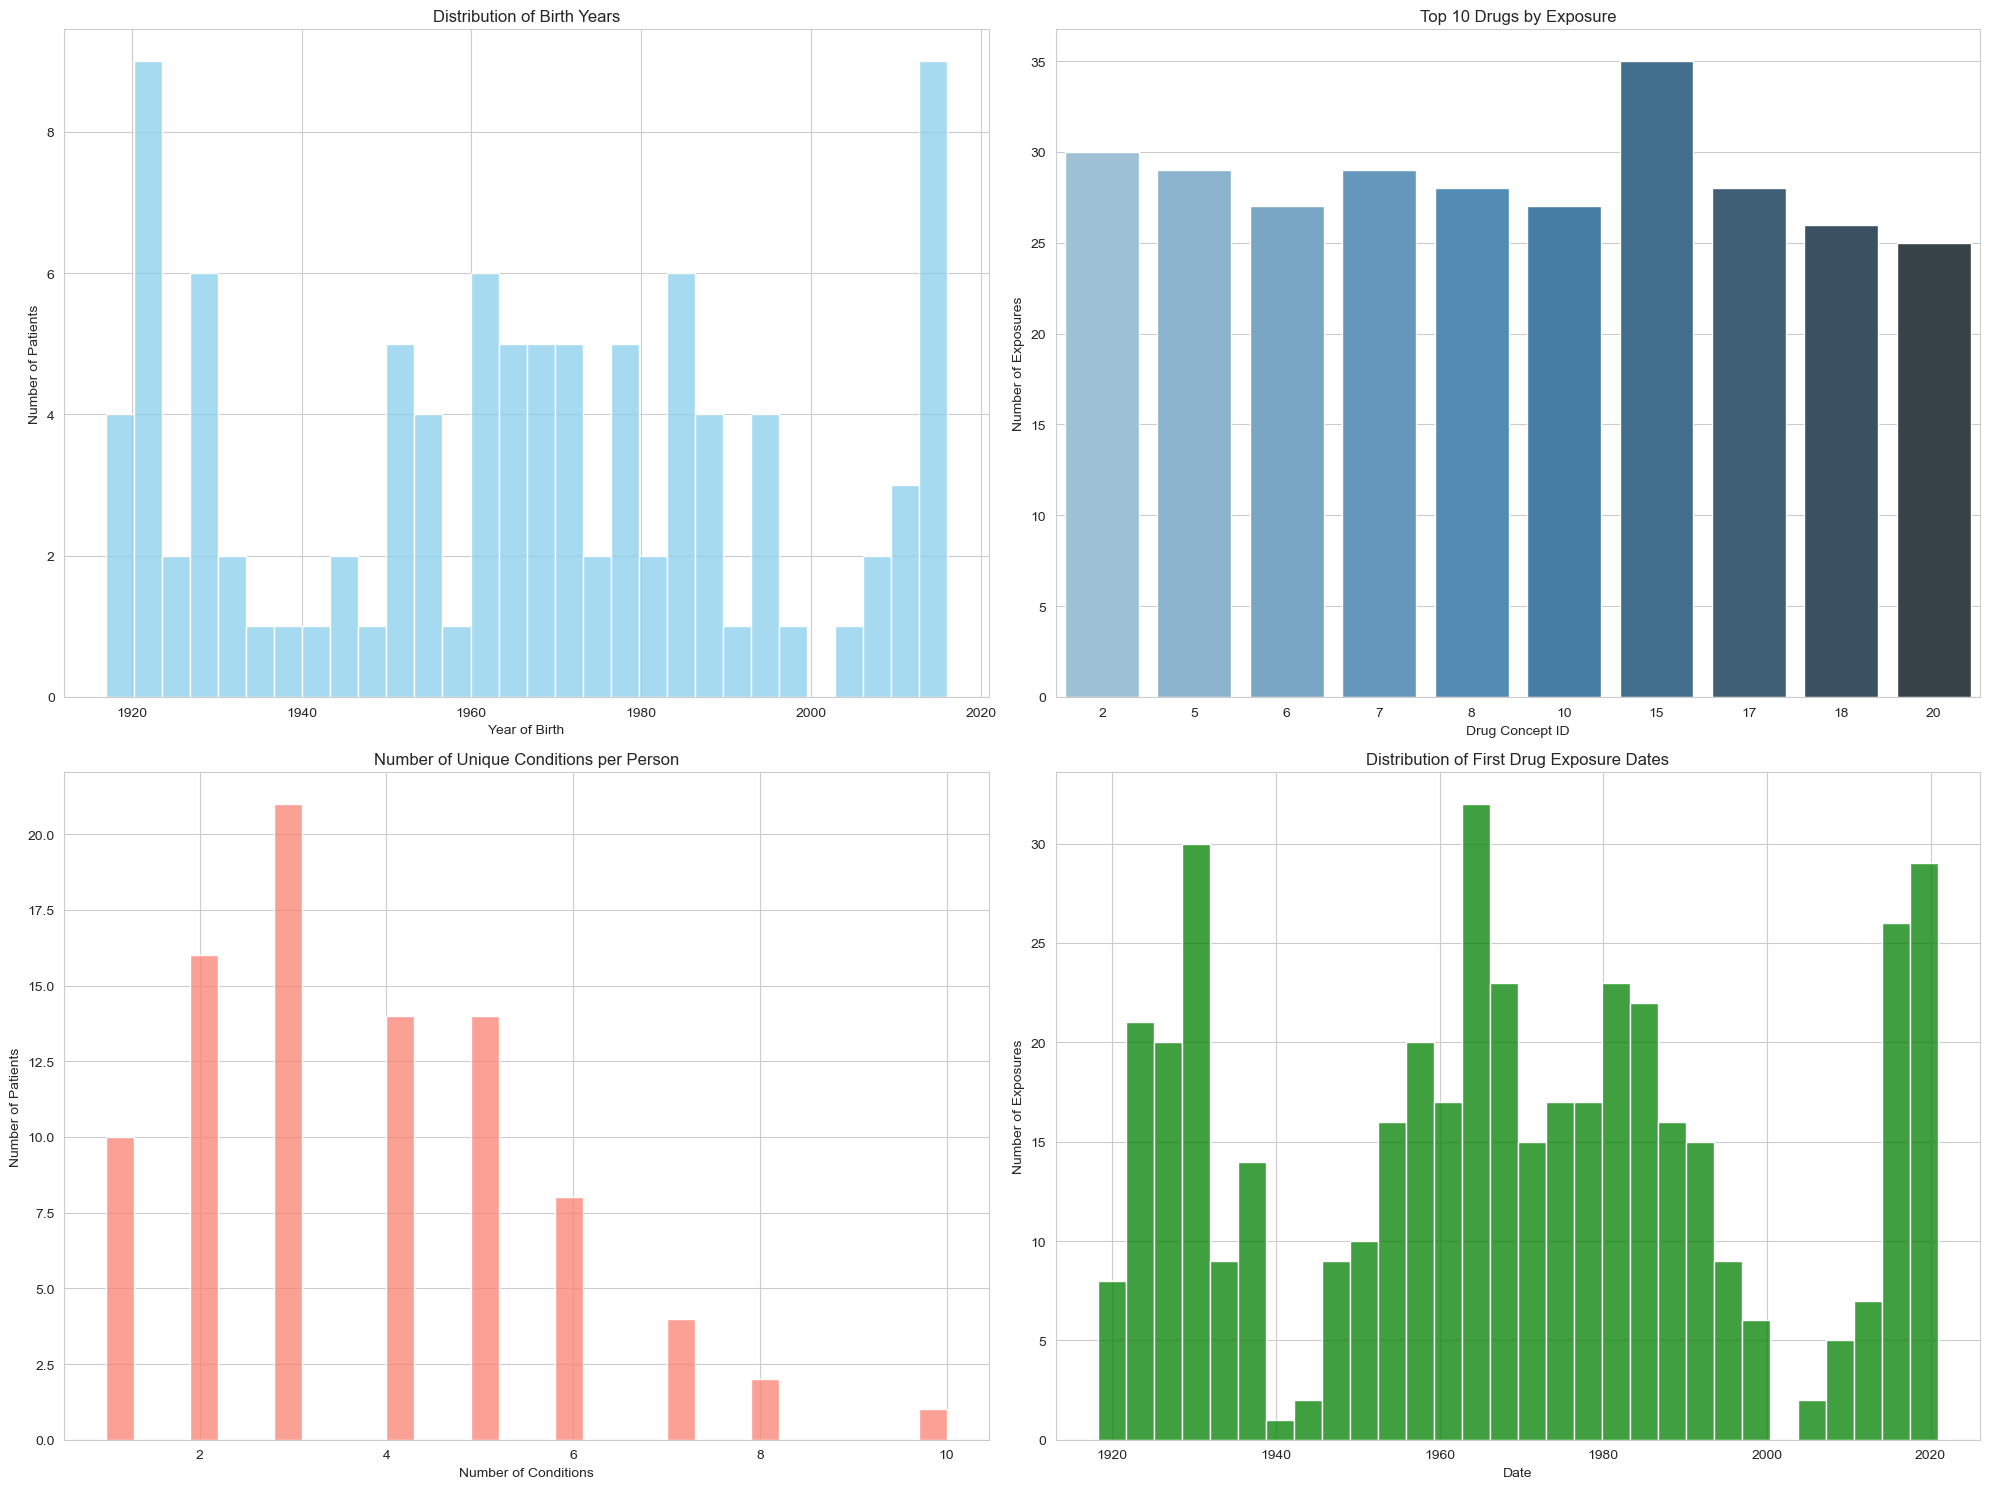

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Initialize the figure
plt.figure(figsize=(20, 15))

# 1. Distribution of Birth Years
plt.subplot(2, 2, 1)
sns.histplot(dat_pers2['year_of_birth'], kde=False, bins=30, color='skyblue')
plt.title('Distribution of Birth Years')
plt.xlabel('Year of Birth')
plt.ylabel('Number of Patients')

# 2. Top Drugs
plt.subplot(2, 2, 2)
top_drugs = dat_drug2['drug_concept_id'].value_counts().head(10)
sns.barplot(x=top_drugs.index, y=top_drugs.values, palette="Blues_d")
plt.title('Top 10 Drugs by Exposure')
plt.xlabel('Drug Concept ID')
plt.ylabel('Number of Exposures')

# 3. Number of Unique Conditions per Person
plt.subplot(2, 2, 3)
num_conditions = dat_conds_by_person.groupby('person_id').size()
sns.histplot(num_conditions, kde=False, bins=30, color='salmon')
plt.title('Number of Unique Conditions per Person')
plt.xlabel('Number of Conditions')
plt.ylabel('Number of Patients')

# 4. Distribution of First Drug Exposure Dates
plt.subplot(2, 2, 4)
sns.histplot(dat_drug_first2['drug_exposure_start_date'], kde=False, bins=30, color='green')
plt.title('Distribution of First Drug Exposure Dates')
plt.xlabel('Date')
plt.ylabel('Number of Exposures')

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()


Text(0.5, 0, 'Days')

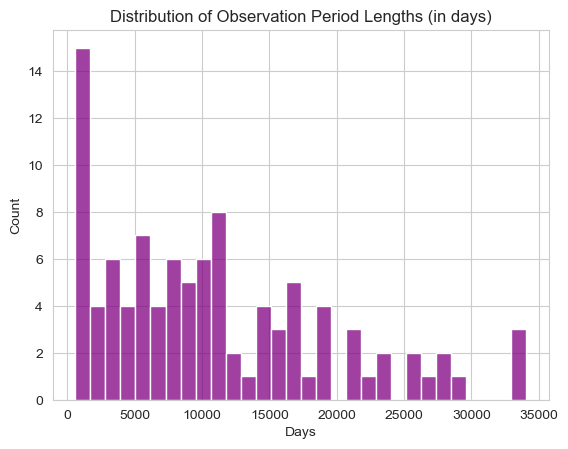

In [50]:
observation_lengths = (dat_obs2['observation_period_end_date'] - dat_obs2['observation_period_start_date']).dt.days
sns.histplot(observation_lengths, bins=30, color='purple')
plt.title('Distribution of Observation Period Lengths (in days)')
plt.xlabel('Days')


Text(0.5, 1.0, 'Top 10 Conditions by Occurrence')

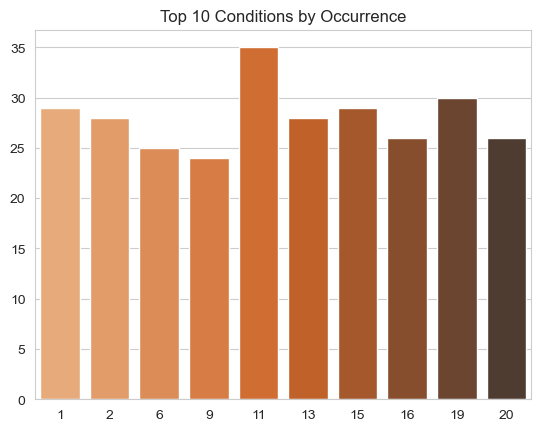

In [51]:
top_conditions = dat_cond2['condition_concept_id'].value_counts().head(10)
sns.barplot(x=top_conditions.index, y=top_conditions.values, palette="Oranges_d")
plt.title('Top 10 Conditions by Occurrence')


Text(0.5, 1.0, 'Heatmap of Drug and Condition Co-occurrences')

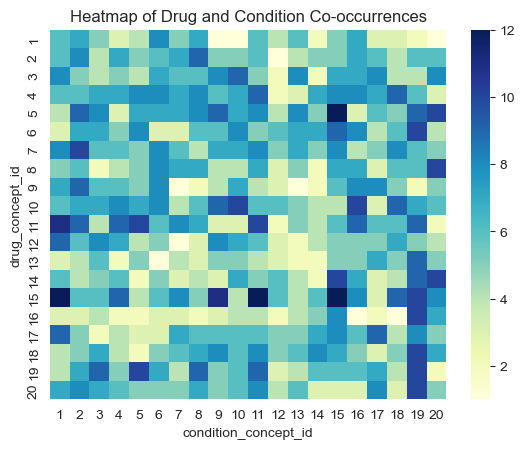

In [52]:
co_occurrence = pd.crosstab(dat_drug_and_cond['drug_concept_id'], dat_drug_and_cond['condition_concept_id'])
sns.heatmap(co_occurrence, cmap='YlGnBu')
plt.title('Heatmap of Drug and Condition Co-occurrences')


Text(0.5, 1.0, 'Boxplot of Age at First Drug Exposure')

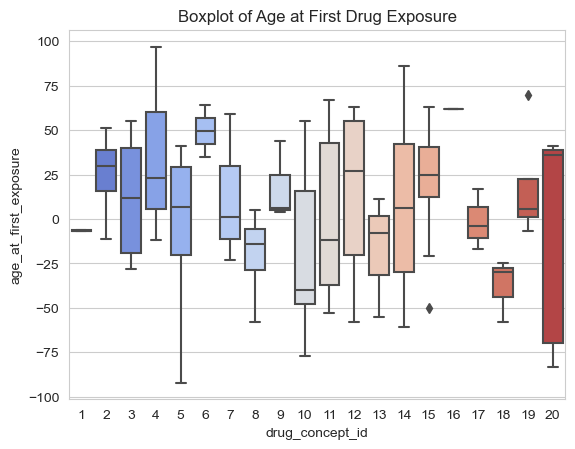

In [53]:
dat_drug_first2['age_at_first_exposure'] = dat_drug_first2['drug_exposure_start_date'].dt.year - dat_pers2['year_of_birth']
sns.boxplot(x='drug_concept_id', y='age_at_first_exposure', data=dat_drug_first2, palette="coolwarm")
plt.title('Boxplot of Age at First Drug Exposure')


Text(0.5, 1.0, 'Timeline of Drug Exposures')

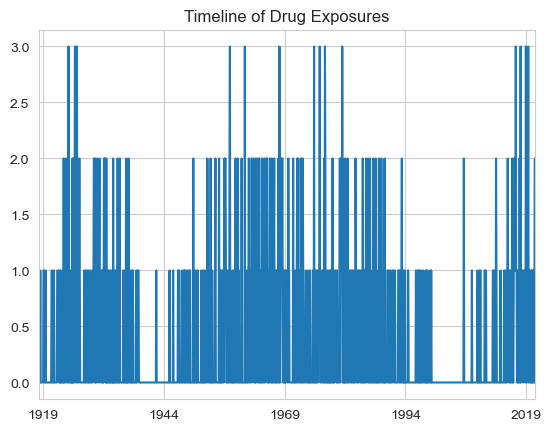

In [54]:
dat_drug2['drug_exposure_start_date'].value_counts().resample('M').sum().plot()
plt.title('Timeline of Drug Exposures')
